In [1]:
# Imports
import numpy as np
import sys

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern

import torch
from torch.utils.data import DataLoader

import neuralop
from neuralop.models import FNO
from neuralop import Trainer, LpLoss, H1Loss
from neuralop.training import AdamW
from neuralop.data.datasets import load_darcy_flow_small, DarcyDataset
from neuralop.utils import count_model_params
from torch.nn import functional as F

import matplotlib.pyplot as plt


In [2]:
# helper functions
def T_push(x, tau=-1, boundary=0):
    """A smooth approximation to the step function, which can be used to get a binary field from the GP sample while maintaining differentiability.
    See Akiyldiz for details.
    Combined with the option to get a hard threshold by setting tau=-1, based on the usual 3-12 normalisation.
    """
    if isinstance(x, np.ndarray):
        if tau == -1:
            return np.where(x < boundary, 3.0, 12.0)
        return 0.5 * np.tanh(tau * x) + 0.5
    else:  # torch tensor
        if tau == -1:
            return torch.where(x < boundary,
                               torch.tensor(3.0),
                               torch.tensor(12.0))
        return 0.5 * torch.tanh(tau * x) + 0.5



def sample_GP_operator(N=64, M=256):
    # Fine-grid wavenumbers — M^2 KL terms instead of N^2
    h_fine = 1 / M  # fine grid spacing for Fourier sampling
    kx = 2 * np.pi * np.fft.fftfreq(M, d=h_fine)
    ky = 2 * np.pi * np.fft.fftfreq(M, d=h_fine)

    KX, KY = np.meshgrid(kx, ky, indexing='ij')

    # Eigenvalues on fine Fourier grid
    A_eigs = KX**2 + KY**2 + 9.0
    Cov_eigs = 1.0 / (A_eigs**2)

    # Sample M^2 independent KL coefficients
    z = np.random.randn(M, M) + 1j * np.random.randn(M, M)
    u_hat = np.sqrt(Cov_eigs) * z

    # IFFT on fine grid
    u_fine = np.fft.ifft2(u_hat).real * M**2  # shape (M, M)

    # Subsample back to coarse N x N grid
    step = M // N
    u_coarse = u_fine[::step, ::step]  # shape (N, N)
    
    return u_coarse

In [13]:
# ============================================================
# PIPELINE WRAPPER FUNCTIONS
# ============================================================

def get_data(
    data_n_train=1_000,
    data_n_tests=[100, 50],
    data_train_resolution=64,
    data_test_resolutions=[64, 128],
    data_batch_size=32,
    data_test_batch_sizes=[32, 32],
):
    """Load the Darcy Flow dataset, renormalise to {3, 12}, and return
    the train/test loaders and data processor.

    Returns
    -------
    train_loader : DataLoader
    test_loaders : dict[int, DataLoader]
    data_processor : DataProcessor
    dataset : DarcyDataset
        Retained so callers can access raw test_dbs for MCMC initialisation.
    """
    dataset = DarcyDataset(
        root_dir="./darcy_data",
        n_train=data_n_train,
        n_tests=data_n_tests,
        train_resolution=data_train_resolution,
        batch_size=data_batch_size,
        test_resolutions=data_test_resolutions,
        test_batch_sizes=data_test_batch_sizes,
    )

    # Renormalise to 3-12 range — only call once
    for test_set in dataset.test_dbs.values():
        test_set.x = T_push(test_set.x, tau=-1, boundary=0.5)
    dataset._train_db.x = T_push(dataset._train_db.x, tau=-1, boundary=0.5)

    train_loader = DataLoader(
        dataset.train_db,
        batch_size=data_batch_size,
        num_workers=1,
        pin_memory=True,
        persistent_workers=False,
    )

    test_loaders = {}
    for res, test_bsize in zip(data_test_resolutions, data_test_batch_sizes):
        test_loaders[res] = DataLoader(
            dataset.test_dbs[res],
            batch_size=test_bsize,
            shuffle=False,
            num_workers=1,
            pin_memory=True,
            persistent_workers=False,
        )

    data_processor = dataset.data_processor

    return train_loader, test_loaders, data_processor, dataset


def train_FNO(
    train_loader,
    data_processor,
    device,
    FNO_n_modes=(25, 25),
    FNO_in_channels=1,
    FNO_out_channels=1,
    FNO_hidden_channels=32,
    FNO_n_layers=4,
    FNO_factorization="tucker",
    FNO_nonlinearity=F.gelu,
    TRAIN_epochs=150,
    save_dir="./checkpoints",
):
    """Instantiate and train an FNO on the given training loader.

    Returns
    -------
    model : trained FNO
    """
    model = FNO(
        n_modes=FNO_n_modes,
        in_channels=FNO_in_channels,
        out_channels=FNO_out_channels,
        hidden_channels=FNO_hidden_channels,
        n_layers=FNO_n_layers,
        factorization=FNO_factorization,
        non_linearity=FNO_nonlinearity,
    )

    model = model.to(device)

    n_params = count_model_params(model)
    print(f"\nOur model has {n_params} parameters.")
    sys.stdout.flush()

    optimizer = AdamW(model.parameters(), lr=8e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

    l2loss = LpLoss(d=2, p=2)
    h1loss = H1Loss(d=2)
    train_loss = h1loss
    eval_losses = {"h1": h1loss, "l2": l2loss}

    trainer = Trainer(
        model=model,
        n_epochs=TRAIN_epochs,
        device=device,
        data_processor=data_processor,
        wandb_log=False,
        eval_interval=5,
        use_distributed=False,
        # verbose=True,
    )

    torch.serialization.add_safe_globals([torch._C._nn.gelu])
    torch.serialization.add_safe_globals([neuralop.layers.spectral_convolution.SpectralConv])

    trainer.train(
        train_loader=train_loader,
        test_loaders={},
        optimizer=optimizer,
        scheduler=scheduler,
        regularizer=False,
        training_loss=train_loss,
        save_every=5,
        save_dir=save_dir,
    )

    return model


def run_MCMC(
    model,
    data_processor,
    true_observations,
    device,
    MCMC_delta=0.00025,
    MCMC_n_iterations=40_000,
    MCMC_tau=-1,
    n_chains=1,
    exploration_depth=10,
    adapt_interval=1_000,
    target_acceptance=0.234,
    seed=None,
):
    """Run pCN MCMC inference on a single test point.

    Parameters
    ----------
    model : trained FNO
    data_processor : DataProcessor
        Used inside log_likelihood for unnormalisation.
    true_observations : torch.Tensor, shape (1, 1, H, W)
        Observed flow field to condition on.
    device : torch.device

    Returns
    -------
    dict with keys:
        theta_evolution  : list of np.ndarray  — full chain of theta samples
        loss_evolution   : list of float        — log-likelihood at each step
        accepted         : list of 0/1          — acceptance indicators
        best_theta       : np.ndarray           — best theta across warm-up chains
        best_u           : np.ndarray           — corresponding latent GP variable
        sigma            : float                — data noise std used
    """
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)


    def log_likelihood(x: torch.Tensor, y: torch.Tensor, model, sigma=0.5275) -> torch.Tensor:
        """Inputs:
        - x: input tensor (location measurements of field θ)
        - y: observed output tensor (e.g., solution field u at locations x)
        - model: the trained FNO model that maps x to predicted y
        - sigma: standard deviation of the Gaussian likelihood
        Returns:
        - log-likelihood of observing y given x under the model's predictions"""
        # Ensure x and y are 4D tensors with shape (1, 1, height, width)
        # Ensure both x and y are on the same device as the model
        # x = x.to(device)
        # y = y.to(device)
        # Assuming Gaussian likelihood with fixed variance
        with torch.no_grad():
            forwards = model(x)
            mean = data_processor.out_normalizer.mean.to(device)  # Move to device
            std = data_processor.out_normalizer.std.to(device)    # Move to device
            forwards = forwards * std + mean
        forwards = forwards[0, 0]  # need .cpu() before .numpy()
        ll = -0.5 * torch.sum((y - forwards) ** 2).item() / sigma**2
        return ll

    from collections import deque

    sigma = true_observations.std().item()
    true_observations = true_observations.to(device)

    # # --- Warm-up: multi-chain exploration to find a good starting point ---
    # best_ll = -np.inf
    # best_theta = None
    # best_u = None

    # for chain in range(n_chains):
    #     accepted_warmup = []
    #     u_0 = sample_GP_operator()
    #     theta_0 = T_push(u_0, tau=MCMC_tau)
    #     theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    #     ll_current = log_likelihood(theta_0_tensor, true_observations, model, sigma=sigma)

    #     for i in range(exploration_depth):
    #         u_proposal = np.sqrt(1 - 2 * MCMC_delta) * u_0 + np.sqrt(2 * MCMC_delta) * sample_GP_operator()
    #         theta_proposal = T_push(u_proposal, tau=MCMC_tau)
    #         theta_proposal_tensor = torch.tensor(theta_proposal, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    #         ll_proposal = log_likelihood(theta_proposal_tensor, true_observations, model, sigma=sigma)
    #         acceptance_prob = min(1, np.exp(ll_proposal - ll_current))

    #         if np.random.rand() < acceptance_prob:
    #             theta_0 = theta_proposal
    #             u_0 = u_proposal
    #             theta_0_tensor = theta_proposal_tensor
    #             ll_current = ll_proposal
    #             accepted_warmup += [1]
    #         else:
    #             accepted_warmup += [0]

    #     if ll_current > best_ll:
    #         best_ll = ll_current
    #         best_theta = theta_0
    #         best_u = u_0

    # --- Main chain from best starting point ---
    theta_evolution = []
    loss_evolution = []
    accepted = []
    nll_window = deque(maxlen=200)
    n_accepted_window = 0

    u_0 = sample_GP_operator()
    theta_0 = T_push(u_0, tau=MCMC_tau)


    theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    ll_current = log_likelihood(theta_0_tensor, true_observations, model, sigma=sigma)

    for i in range(MCMC_n_iterations):
        u_proposal = np.sqrt(1 - 2 * MCMC_delta) * u_0 + np.sqrt(2 * MCMC_delta) * sample_GP_operator()
        theta_proposal = T_push(u_proposal, tau=MCMC_tau)
        theta_proposal_tensor = torch.tensor(theta_proposal, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        ll_proposal = log_likelihood(theta_proposal_tensor, true_observations, model, sigma=sigma)
        acceptance_prob = min(1, np.exp(ll_proposal - ll_current))

        if np.random.rand() < acceptance_prob:
            theta_0 = theta_proposal
            u_0 = u_proposal
            theta_0_tensor = theta_proposal_tensor
            ll_current = ll_proposal
            accepted += [1]
            n_accepted_window += 1
        else:
            accepted += [0]

        theta_evolution.append(theta_0)
        loss_evolution.append(ll_current)
        nll_window.append(-ll_current)

        if (i + 1) % adapt_interval == 0:
            acceptance_rate = n_accepted_window / adapt_interval
            n_accepted_window = 0
            avg_nll = np.mean(nll_window)
            print(f"Iteration {i+1}/{MCMC_n_iterations} | "
                  f"accept={acceptance_rate:.3f} | "
                  f"delta={MCMC_delta:.5f} | "
                  f"avg NLL (last 200)={avg_nll:.3f}")

    return {
        "theta_evolution": theta_evolution,
        "loss_evolution":  loss_evolution,
        "accepted":        accepted,
        "best_theta":      theta_0,
        "best_u":          u_0,
        "sigma":           sigma,
    }

In [75]:
import numpy as np
from mpi4py import MPI
from dolfinx import mesh, fem
from dolfinx.fem.petsc import LinearProblem
import ufl
from scipy.interpolate import griddata
import torch

def solve_FEM(theta):
    """
    Solve Darcy flow PDE given a discretised permeability field.
    
    Parameters
    ----------
    theta : np.ndarray or torch.Tensor of shape (H, W)
        Binary/continuous permeability field (values in {3, 12} or similar).
        The mesh resolution is inferred adaptively from the input shape.
    
    Returns
    -------
    u_out : same type and shape as theta
        The pressure/flow field solving -∇·(a(x)∇u) = 1 on [0,1]²
        with homogeneous Dirichlet BCs.
    """
    is_tensor = isinstance(theta, torch.Tensor)
    theta_np = theta.numpy() if is_tensor else np.asarray(theta)

    H, W = theta_np.shape  # infer resolution from input

    # ── 1. MESH ───────────────────────────────────────────────────────────────
    domain = mesh.create_unit_square(MPI.COMM_WORLD, H-1, W-1)

    # ── 2. PERMEABILITY FIELD a(x) ────────────────────────────────────────────
    # DG0: piecewise constant per triangle cell
    V_k = fem.functionspace(domain, ("DG", 0))
    a_func = fem.Function(V_k)

    tdim = domain.topology.dim
    num_cells = domain.topology.index_map(tdim).size_local
    midpoints = mesh.compute_midpoints(domain, tdim, np.arange(num_cells))

    # Map each cell midpoint → pixel index in theta
    ix = np.clip((midpoints[:, 0] * W).astype(int), 0, W)
    iy = np.clip((midpoints[:, 1] * H).astype(int), 0, H)

    # Permeability
    a_func.x.array[:] = theta_np[iy, ix]

    # ── 3. FUNCTION SPACE & BCs ───────────────────────────────────────────────
    V = fem.functionspace(domain, ("Lagrange", 1))

    fdim = tdim - 1
    all_boundary_facets = mesh.locate_entities_boundary(
        domain, fdim, lambda x: np.full(x.shape[1], True, dtype=bool)
    )
    bc = fem.dirichletbc(
        fem.Constant(domain, 0.0),
        fem.locate_dofs_topological(V, fdim, all_boundary_facets),
        V,
    )

    # ── 4. VARIATIONAL FORM ───────────────────────────────────────────────────
    # -∇·(a(x)∇u) = 1  →  ∫ a ∇u·∇v dx = ∫ v dx
    u = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)
    a_form = a_func * ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
    L_form = v * ufl.dx

    # ── 5. SOLVE ──────────────────────────────────────────────────────────────
    problem = LinearProblem(
        a_form, L_form, bcs=[bc],
        petsc_options_prefix="darcy",
        petsc_options={
            "ksp_type": "cg",
            "pc_type": "hypre",
            "pc_hypre_type": "boomeramg",
            "ksp_rtol": 1e-12,
        },
    )
    uh = problem.solve()

    # ── 6. INTERPOLATE BACK ONTO H×W GRID ────────────────────────────────────
    coords = V.tabulate_dof_coordinates()[:, :2]
    u_vals = uh.x.array.real

    grid_x, grid_y = np.meshgrid(
        np.linspace(0, 1, W), np.linspace(0, 1, H)
    )
    u_grid = griddata(coords, u_vals, (grid_x, grid_y), method="linear")

    # Fill any boundary NaNs from griddata with 0 (matches Dirichlet BC)
    u_grid = np.nan_to_num(u_grid, nan=0.0)

    # ── 7. RETURN SAME TYPE AS INPUT ──────────────────────────────────────────
    if is_tensor:
        return torch.tensor(u_grid, dtype=theta.dtype)
    return u_grid.astype(theta_np.dtype)


In [4]:
# Activate GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
train_loader, test_loaders, data_processor, dataset = get_data()
true_field = dataset.test_dbs[64].x[0, 0].unsqueeze(0).unsqueeze(0)
true_observations = dataset.test_dbs[64].y[0, 0].unsqueeze(0).unsqueeze(0)
model = train_FNO(train_loader, data_processor, device)


Loading test db for resolution 64 with 100 samples 
Loading test db for resolution 128 with 50 samples 

Our model has 2698289 parameters.
Training on 1000 samples
Testing on [] samples         on resolutions [].
Raw outputs of shape torch.Size([32, 1, 64, 64])


/home/ghazi/anaconda3/envs/darcy-env/lib/python3.11/site-packages/torch/nn/modules/module.py:1790: UserWarning: FNO.forward() received unexpected keyword arguments: ['y']. These arguments will be ignored.
  return forward_call(*args, **kwargs)
/home/ghazi/anaconda3/envs/darcy-env/lib/python3.11/site-packages/neuralop/training/trainer.py:536: UserWarning: H1Loss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  loss += training_loss(out, **sample)


[0] time=1.45, avg_loss=0.8869, train_err=27.7165
Eval: 
[Rank 0]: saved training state to ./checkpoints
[5] time=1.23, avg_loss=0.1968, train_err=6.1496
Eval: 
[Rank 0]: saved training state to ./checkpoints
[10] time=1.20, avg_loss=0.1537, train_err=4.8036
Eval: 
[Rank 0]: saved training state to ./checkpoints
[15] time=1.21, avg_loss=0.1200, train_err=3.7487
Eval: 
[Rank 0]: saved training state to ./checkpoints
[20] time=1.23, avg_loss=0.1116, train_err=3.4866
Eval: 
[Rank 0]: saved training state to ./checkpoints
[25] time=1.24, avg_loss=0.0810, train_err=2.5316
Eval: 
[Rank 0]: saved training state to ./checkpoints
[30] time=1.21, avg_loss=0.0786, train_err=2.4550
Eval: 
[Rank 0]: saved training state to ./checkpoints
[35] time=1.20, avg_loss=0.0795, train_err=2.4831
Eval: 
[Rank 0]: saved training state to ./checkpoints
[40] time=1.24, avg_loss=0.0797, train_err=2.4909
Eval: 
[Rank 0]: saved training state to ./checkpoints
[45] time=1.24, avg_loss=0.1173, train_err=3.6649
Eval: 

TypeError: must be real number, not NoneType

In [11]:
model = model.to(device)
result = run_MCMC(model, data_processor, true_observations, device, MCMC_n_iterations=10000, seed=42)
# np.save(f"ablation_results/mcmc_point_{i}.npy", result)

Iteration 1000/10000 | accept=0.198 | delta=0.00025 | avg NLL (last 200)=514.862
Iteration 2000/10000 | accept=0.093 | delta=0.00025 | avg NLL (last 200)=192.318
Iteration 3000/10000 | accept=0.105 | delta=0.00025 | avg NLL (last 200)=84.018
Iteration 4000/10000 | accept=0.167 | delta=0.00025 | avg NLL (last 200)=73.582
Iteration 5000/10000 | accept=0.178 | delta=0.00025 | avg NLL (last 200)=73.929
Iteration 6000/10000 | accept=0.184 | delta=0.00025 | avg NLL (last 200)=75.045
Iteration 7000/10000 | accept=0.241 | delta=0.00025 | avg NLL (last 200)=61.227
Iteration 8000/10000 | accept=0.224 | delta=0.00025 | avg NLL (last 200)=46.538
Iteration 9000/10000 | accept=0.232 | delta=0.00025 | avg NLL (last 200)=39.593
Iteration 10000/10000 | accept=0.258 | delta=0.00025 | avg NLL (last 200)=42.934


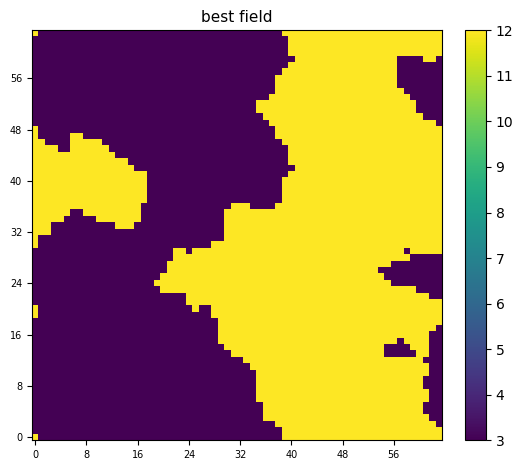

In [26]:
# sanity check plot
best_theta = result["best_theta"]
title = "best field"

fig, ax = plt.subplots()
im = ax.imshow(best_theta, cmap='viridis', interpolation='nearest', origin='lower')
ax.set_title(title, fontsize=11, loc='center', pad=6)
ax.set_xticks(range(0, best_theta.shape[0]-2, 8))
ax.set_yticks(range(0, best_theta.shape[1]-2, 8))
ax.tick_params(labelsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('single_field.png', bbox_inches='tight', dpi=300)
plt.show()

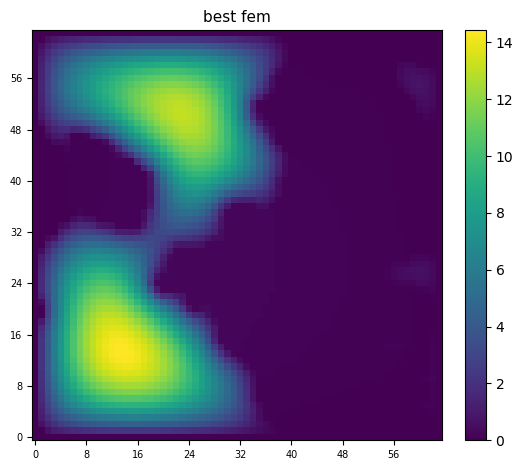

In [27]:
# sanity check plot
best_fem = torch.from_numpy(solve_FEM(best_theta))
title = "best fem"

fig, ax = plt.subplots()
im = ax.imshow(best_fem, cmap='viridis', interpolation='nearest', origin='lower')
ax.set_title(title, fontsize=11, loc='center', pad=6)
ax.set_xticks(range(0, best_fem.shape[0]-2, 8))
ax.set_yticks(range(0, best_fem.shape[1]-2, 8))
ax.tick_params(labelsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('single_field.png', bbox_inches='tight', dpi=300)
plt.show()

In [37]:
print(best_theta.shape)
with torch.no_grad():
    predicted_solution = model(torch.tensor(best_theta, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)).cpu().numpy()[0, 0]


(64, 64)


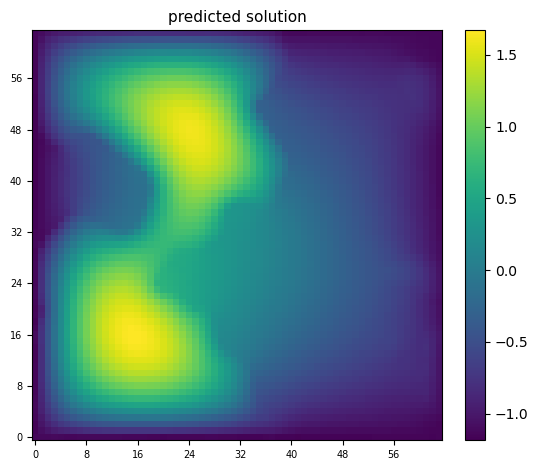

In [38]:
# sanity check plot
title = "predicted solution"

fig, ax = plt.subplots()
im = ax.imshow(predicted_solution, cmap='viridis', interpolation='nearest', origin='lower')
ax.set_title(title, fontsize=11, loc='center', pad=6)
ax.set_xticks(range(0, predicted_solution.shape[0]-2, 8))
ax.set_yticks(range(0, predicted_solution.shape[1]-2, 8))
ax.tick_params(labelsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('single_field.png', bbox_inches='tight', dpi=300)
plt.show()

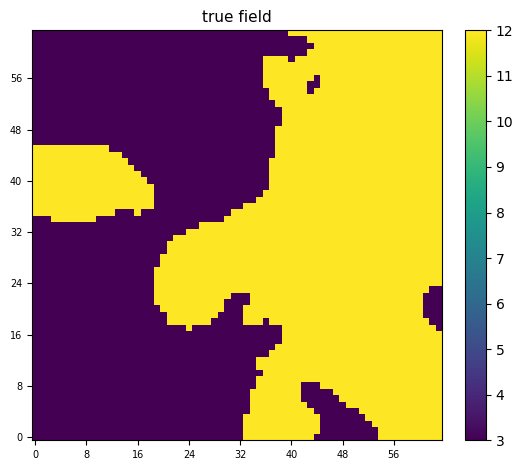

In [64]:
# sanity check plot
true_field = true_field.squeeze(0).squeeze(0)
title = "true field"

fig, ax = plt.subplots()
im = ax.imshow(true_field, cmap='viridis', interpolation='nearest', origin='lower')
ax.set_title(title, fontsize=11, loc='center', pad=6)
ax.set_xticks(range(0, true_field.shape[0]-2, 8))
ax.set_yticks(range(0, true_field.shape[1]-2, 8))
ax.tick_params(labelsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('single_field.png', bbox_inches='tight', dpi=300)
plt.show()

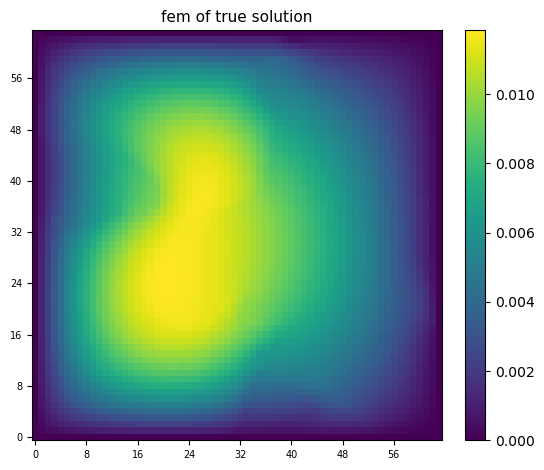

In [79]:
def T_push(x, tau=-1, boundary=0):
    """A smooth approximation to the step function, which can be used to get a binary field from the GP sample while maintaining differentiability.
    See Akiyldiz for details.
    Combined with the option to get a hard threshold by setting tau=-1, based on the usual 3-12 normalisation.
    """
    if isinstance(x, np.ndarray):
        if tau == -1:
            return np.where(x < boundary, 0.0, 1.0)
        return 0.5 * np.tanh(tau * x) + 0.5
    else:  # torch tensor
        if tau == -1:
            return torch.where(x < boundary,
                               torch.tensor(0.0),
                               torch.tensor(1.0))
        return 0.5 * torch.tanh(tau * x) + 0.5



# sanity check plot
observation_fem = solve_FEM(true_field.squeeze(0).squeeze(0))
title = "fem of true solution"

fig, ax = plt.subplots()
im = ax.imshow(observation_fem, cmap='viridis', interpolation='nearest', origin='lower')
ax.set_title(title, fontsize=11, loc='center', pad=6)
ax.set_xticks(range(0, observation_fem.shape[0]-2, 8))
ax.set_yticks(range(0, observation_fem.shape[1]-2, 8))
ax.tick_params(labelsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('single_field.png', bbox_inches='tight', dpi=300)
plt.show()

In [47]:
h1loss = H1Loss(d=2)
best_fem = torch.from_numpy(solve_FEM(best_theta))

h1loss(torch.from_numpy(predicted_solution), observation_fem)

tensor(0.8656)